## 1. Import the libarys

In [334]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 2. Load the data

In [335]:
df = pd.read_csv("../data/raw/data.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Understand the data

In [336]:
df.shape

(1460, 81)

In [337]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [338]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir',
       'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 

In [339]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [340]:
df.describe(include='object').T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


In [341]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [342]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_percent =(missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"MissingCount":missing, "MissingPercent": missing_percent})
missing_df

,MissingCount,MissingPercent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [343]:
numerical_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(include='object').columns

print(f"Numerical Features ({ len(numerical_columns)}):", numerical_columns)
print(f"Categorical Features ({ len(categorical_columns)}):", categorical_columns)

Numerical Features (38): Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')
Categorical Features (43): Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', '

In [344]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


## 4. Data Cleaning

In [345]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for c in none_cols:
    df[c] = df[c].fillna('None')

zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath']
for c in zero_cols:
    if c in df.columns:
        df[c] = df[c].fillna(0)

df['LotFrontage'] = df['LotFrontage'].fillna(
    df.groupby('Neighborhood')['LotFrontage'].transform('median')
)

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [346]:
df.isnull().sum().sum()

np.int64(0)

In [347]:
df_clean = df.drop(columns=['Id'])
df_clean.shape

(1460, 80)

## 5. EDA

### 5.1 Target Variable Distribution

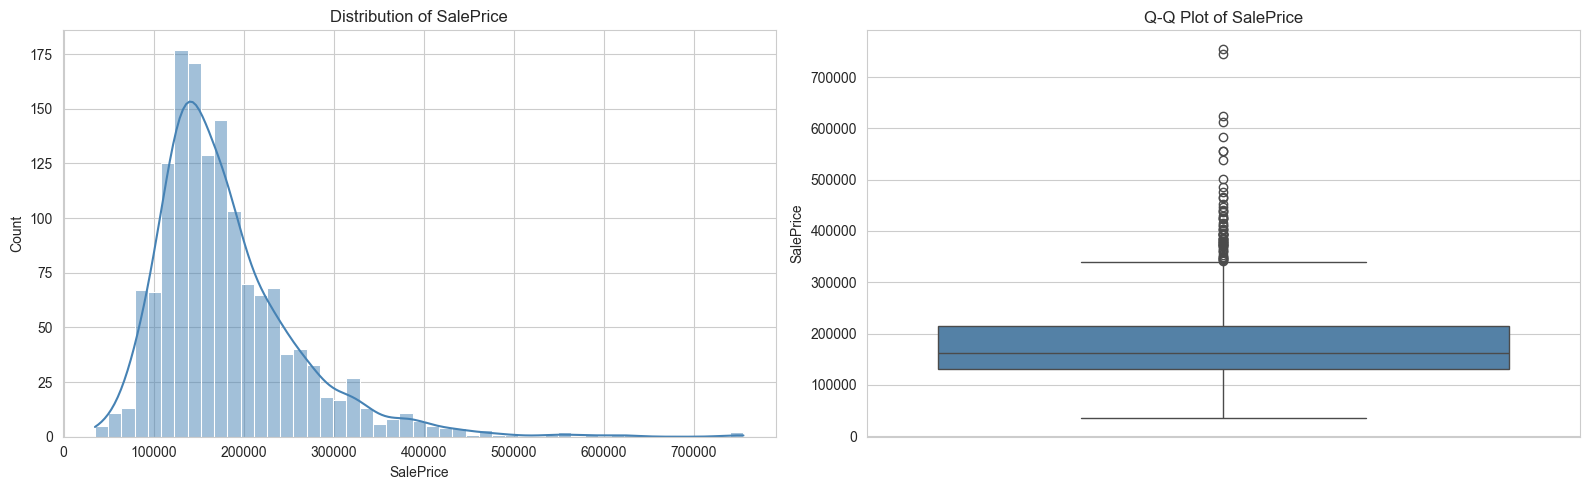

Skewness: 1.883
Kurtosis: 6.536


In [348]:
plt.figure(figsize=(16, 5))

plt.subplot(1,2,1)
sns.histplot(df_clean['SalePrice'], kde=True, color='steelblue')
plt.title("Distribution of SalePrice")

plt.subplot(1,2,2)
sns.boxplot(df_clean['SalePrice'], color='steelblue')
plt.title("Q-Q Plot of SalePrice")

plt.tight_layout()
plt.show()

print(f"Skewness: {df_clean['SalePrice'].skew():.3f}")
print(f"Kurtosis: {df_clean['SalePrice'].kurt():.3f}")

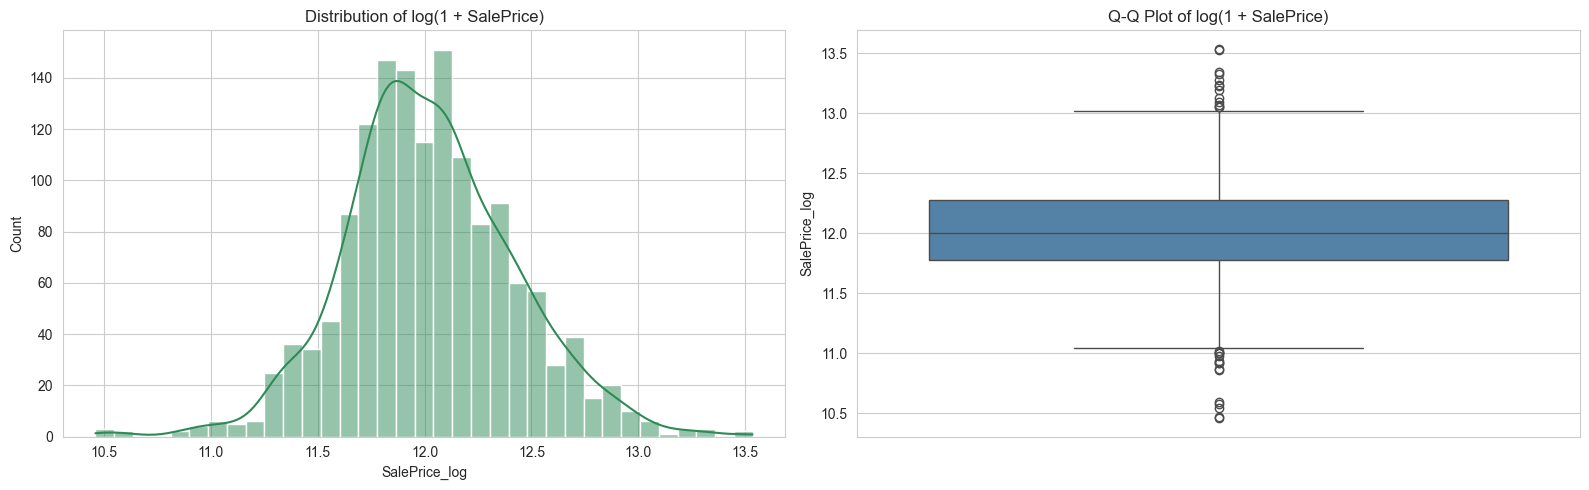

Skewness: 0.121
Kurtosis: 0.810


In [349]:
df_clean["SalePrice_log"] = np.log1p(df_clean["SalePrice"])

plt.figure(figsize=(16, 5))

plt.subplot(1,2,1)
sns.histplot(df_clean['SalePrice_log'], kde=True, color='seagreen')
plt.title("Distribution of log(1 + SalePrice)")

plt.subplot(1,2,2)
sns.boxplot(df_clean['SalePrice_log'], color='steelblue')
plt.title("Q-Q Plot of log(1 + SalePrice)")

plt.tight_layout()
plt.savefig("../images/eda_plots/Target_variable.png")
plt.show()

print(f"Skewness: {df_clean['SalePrice_log'].skew():.3f}")
print(f"Kurtosis: {df_clean['SalePrice_log'].kurt():.3f}")

### 5.2 Univarient Analysis

36 numerical features


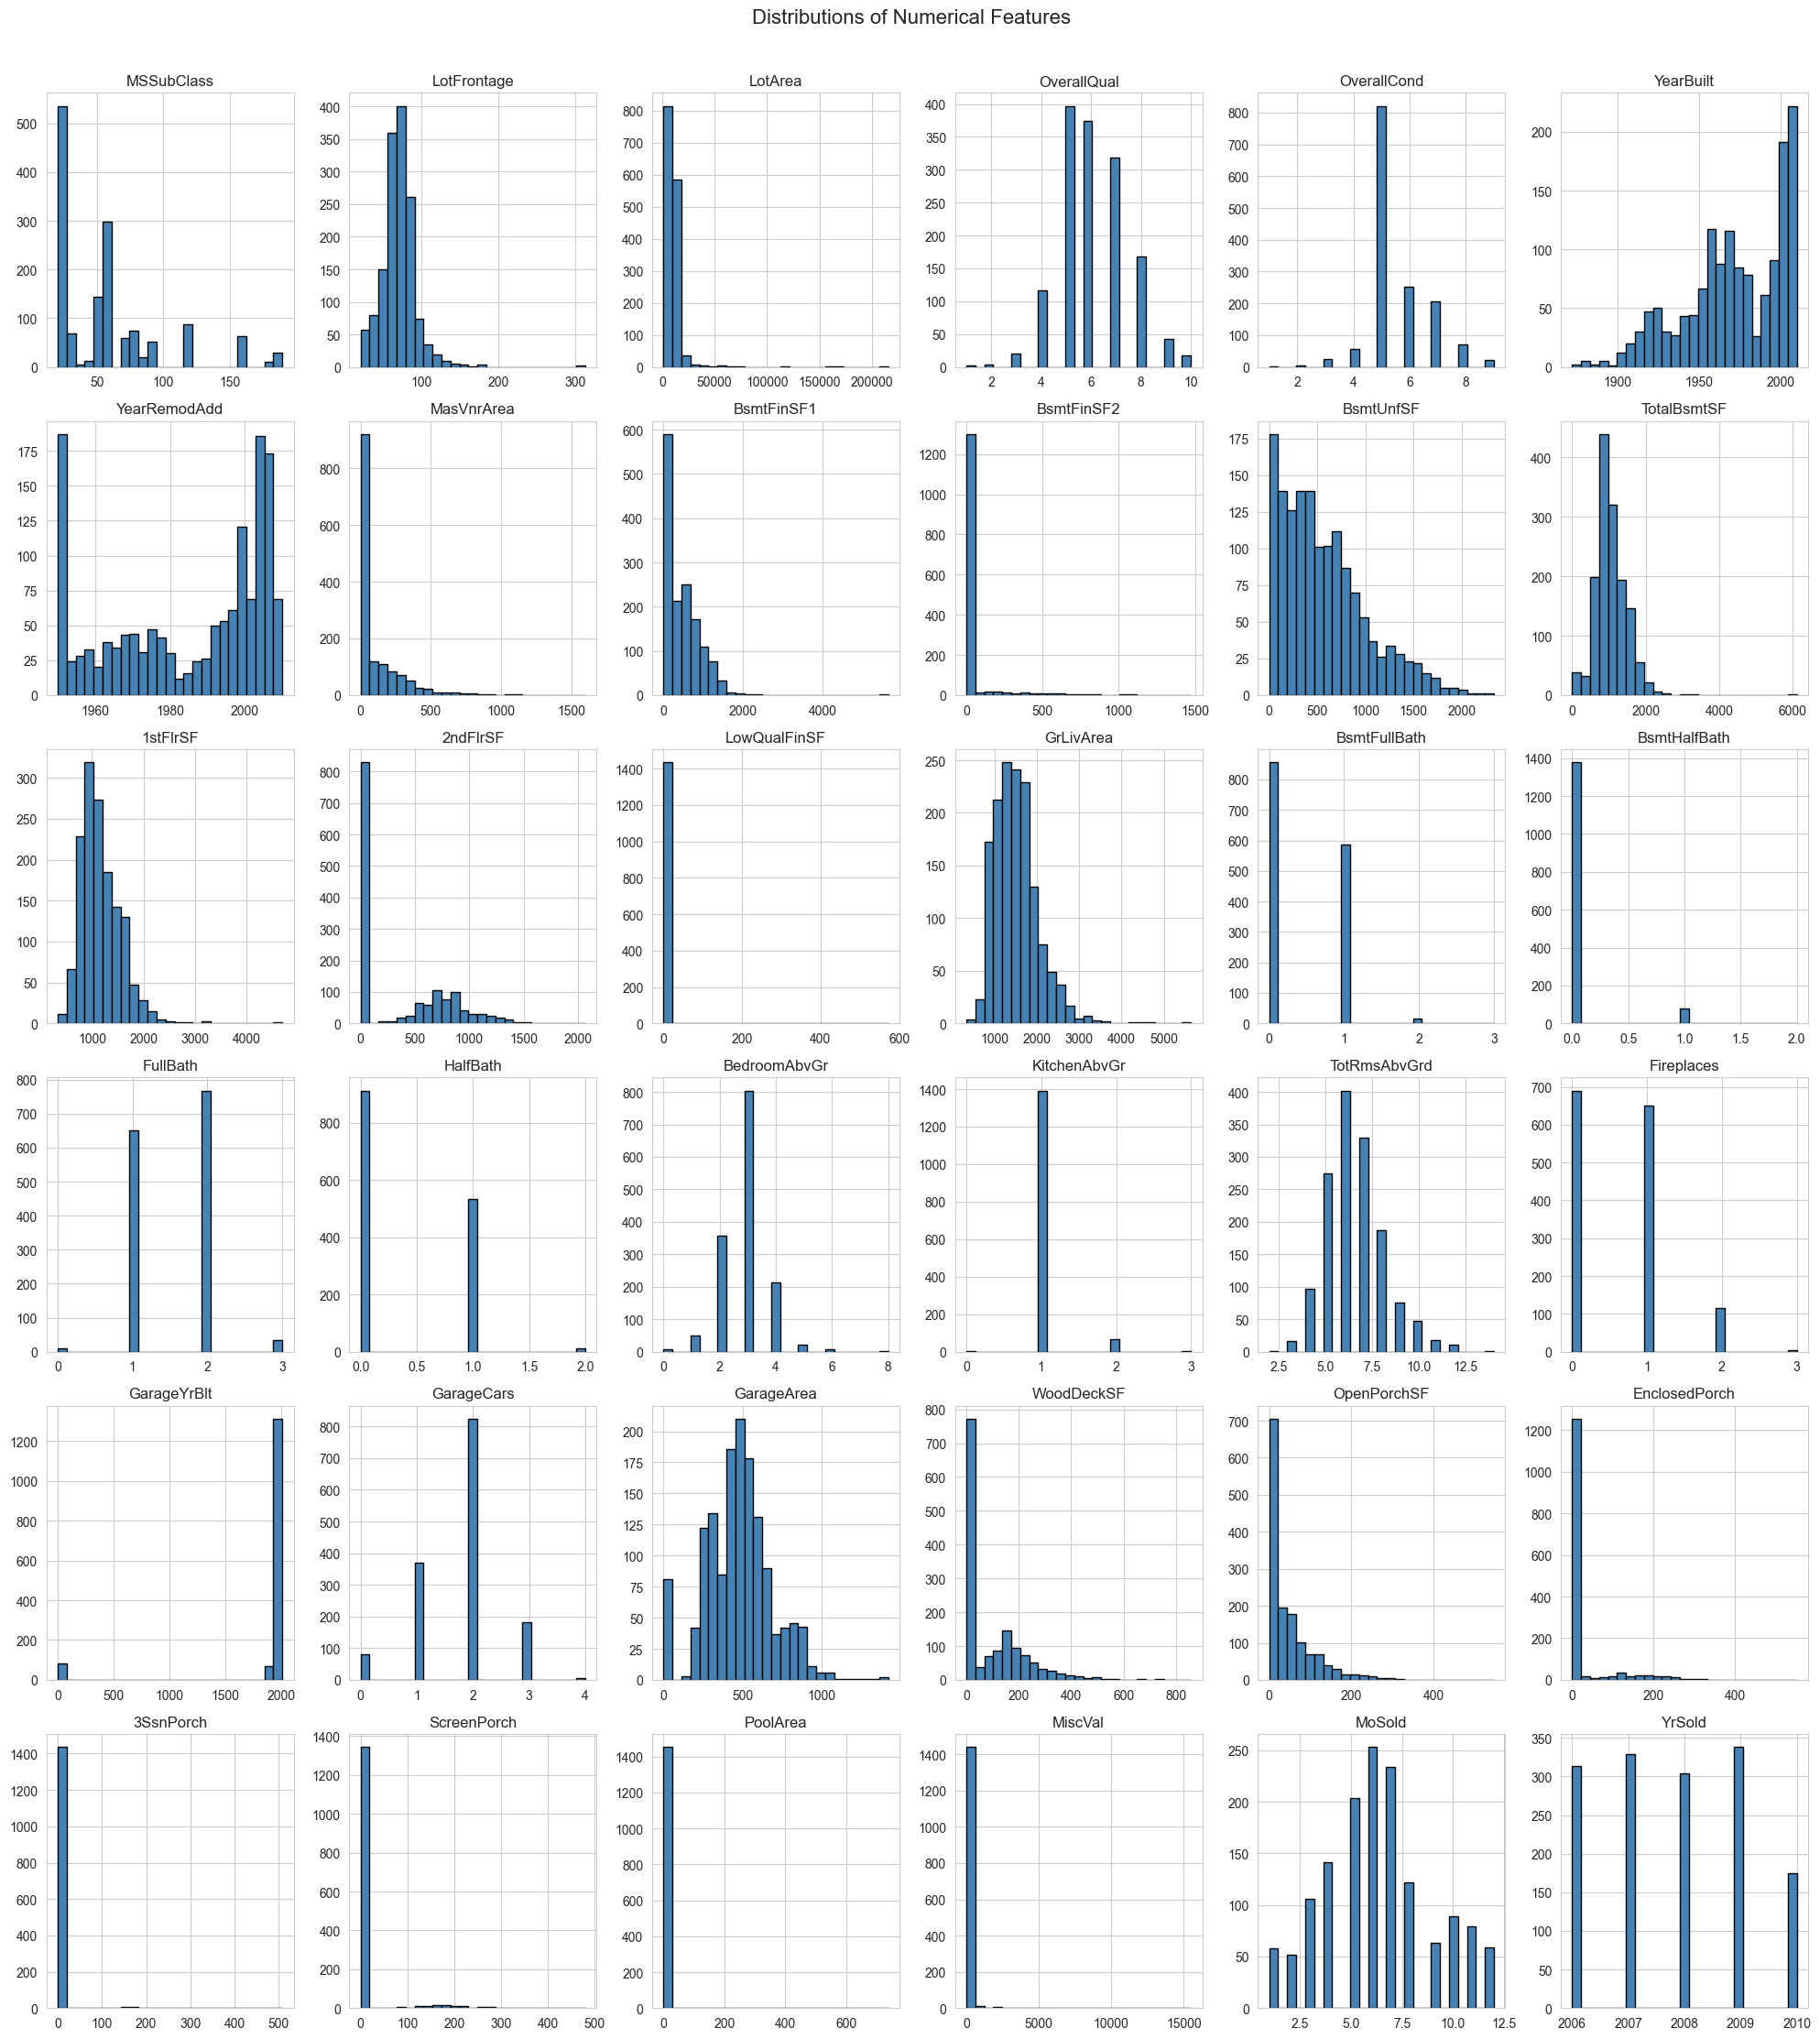

In [350]:
num_features = [c for c in df_clean.select_dtypes(include=[np.number]).columns
                if c not in ['SalePrice', 'SalePrice_log']]
print(f'{len(num_features)} numerical features')

df_clean[num_features].hist(bins=25, figsize=(20, 22), color='steelblue', edgecolor='black')
plt.suptitle('Distributions of Numerical Features', y=1.01, fontsize=16)
plt.tight_layout()
plt.savefig("../images/eda_plots/Distributions_of_Numerical_Features.png")
plt.show()

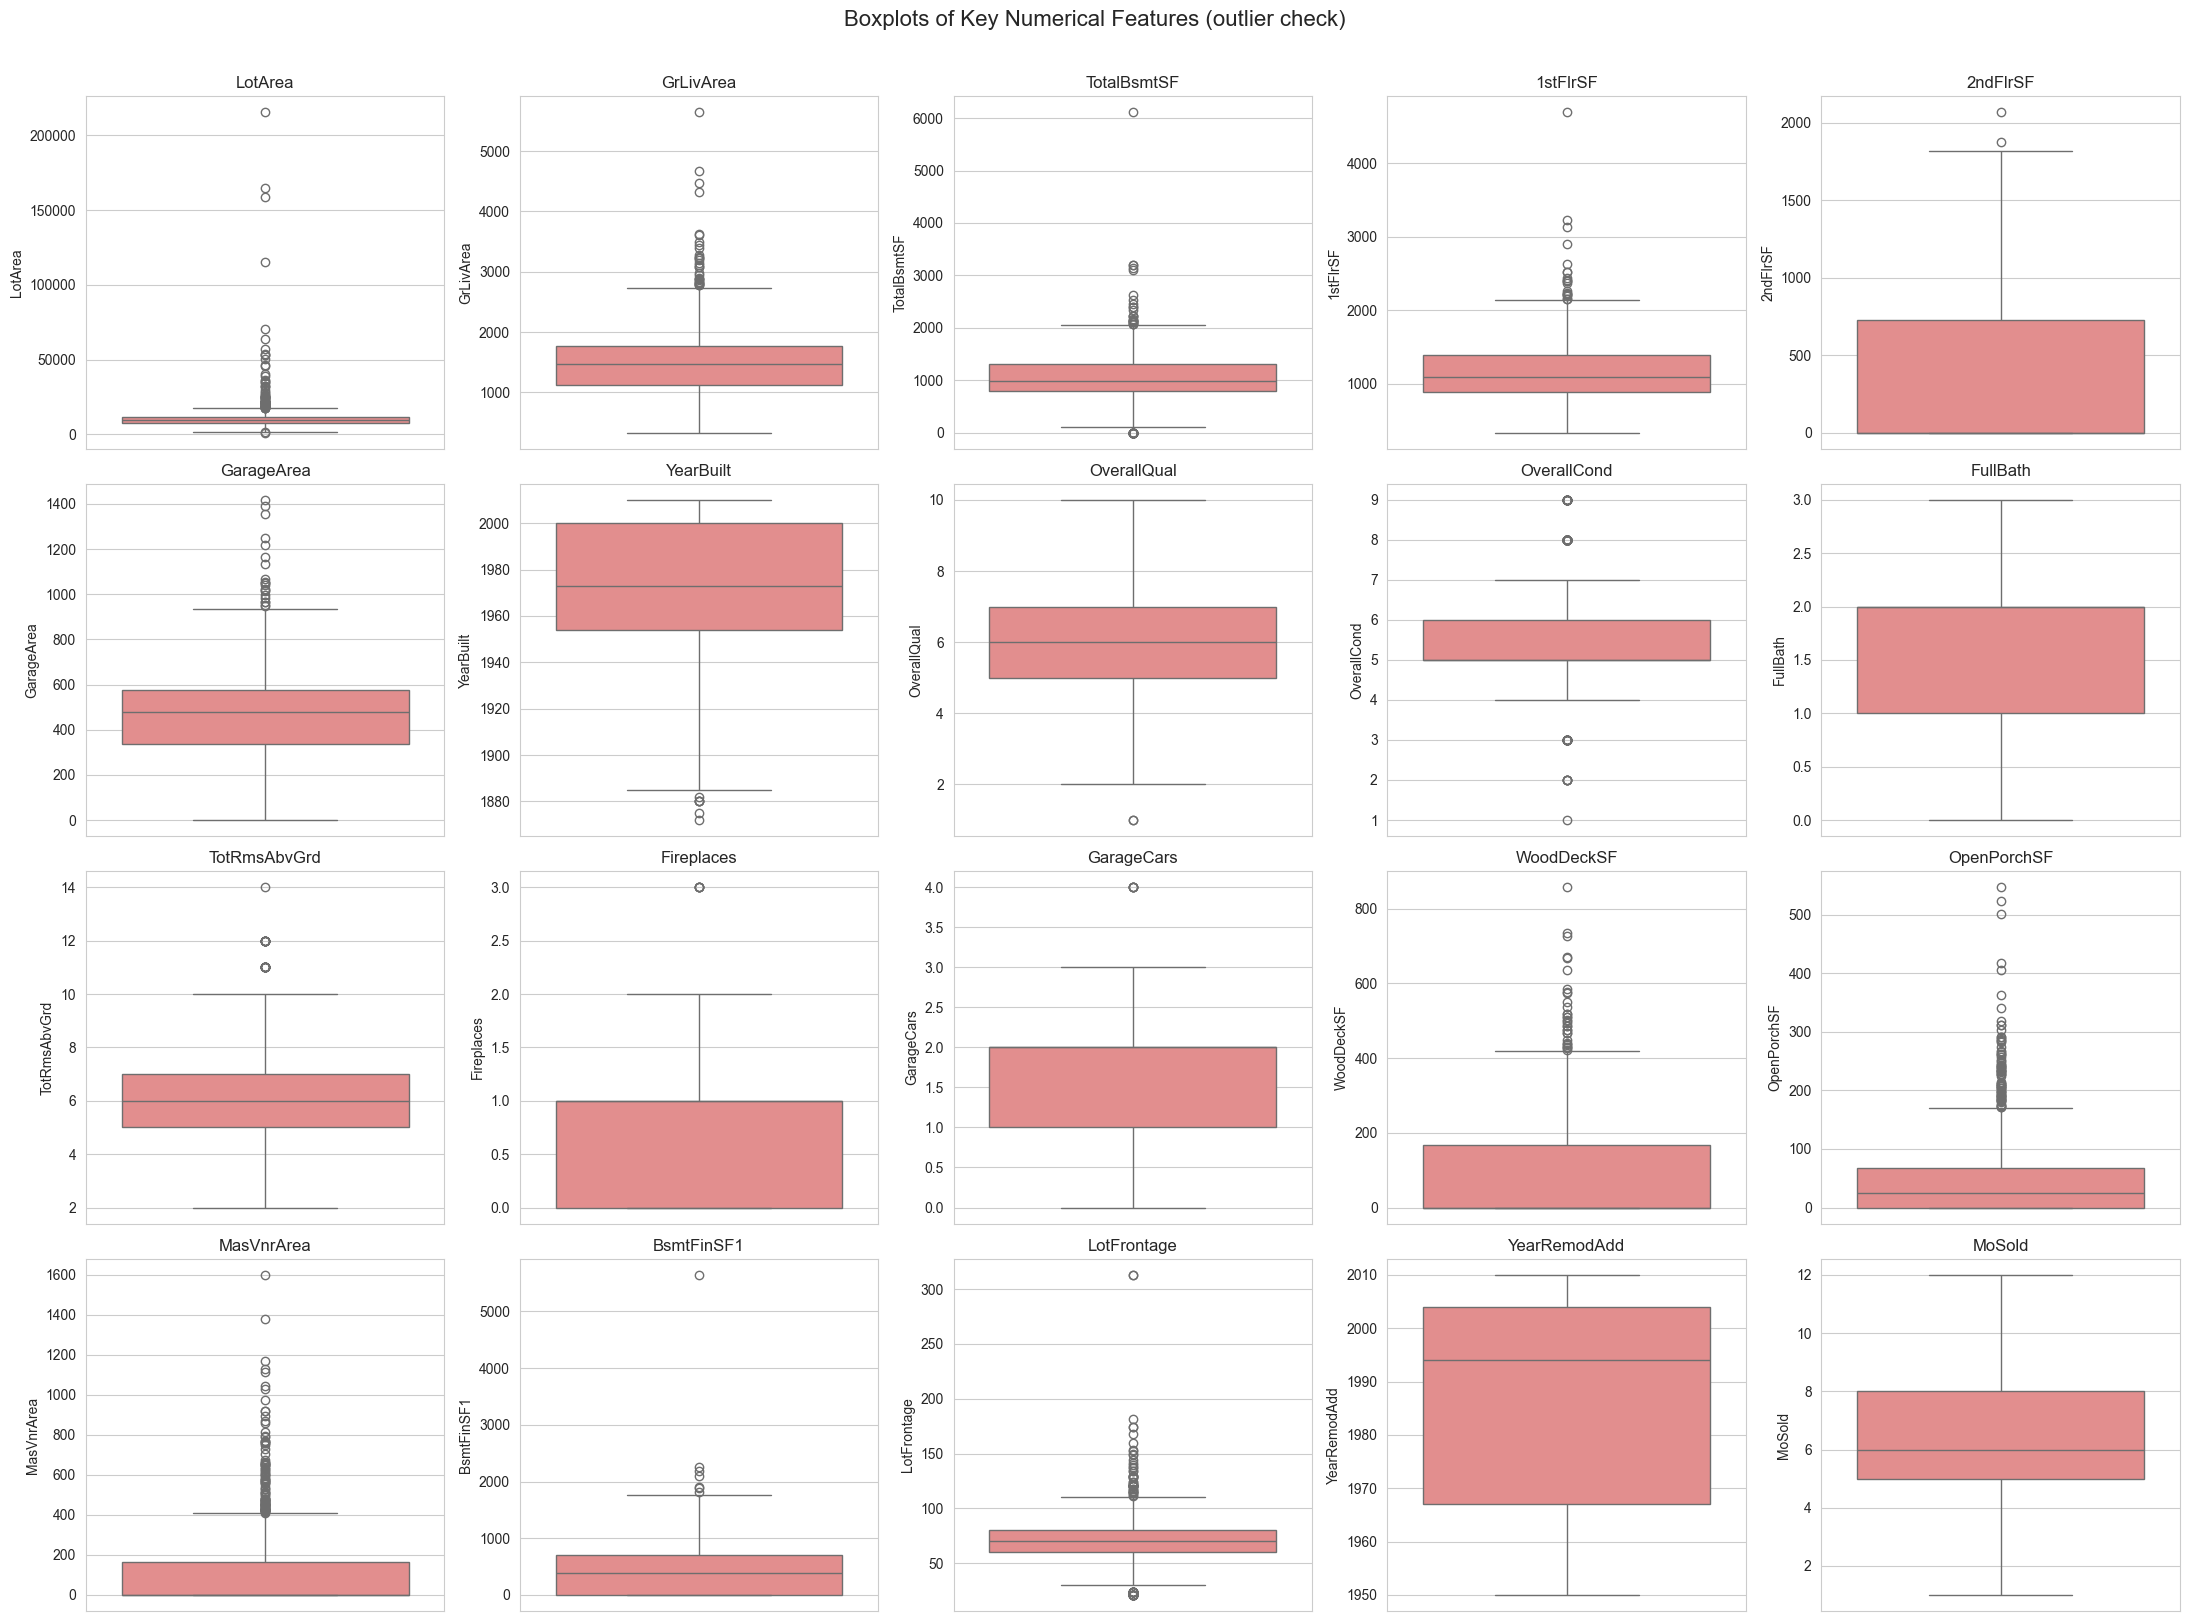

In [351]:
fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()
key_num = ['LotArea','GrLivArea','TotalBsmtSF','1stFlrSF','2ndFlrSF','GarageArea',
           'YearBuilt','OverallQual','OverallCond','FullBath','TotRmsAbvGrd',
           'Fireplaces','GarageCars','WoodDeckSF','OpenPorchSF','MasVnrArea',
           'BsmtFinSF1','LotFrontage','YearRemodAdd','MoSold']
for i, col in enumerate(key_num):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)
plt.suptitle('Boxplots of Key Numerical Features (outlier check)', y=1.01, fontsize=16)
plt.tight_layout()
plt.savefig("../images/eda_plots/Boxplots_categorical_feature.png")
plt.show()

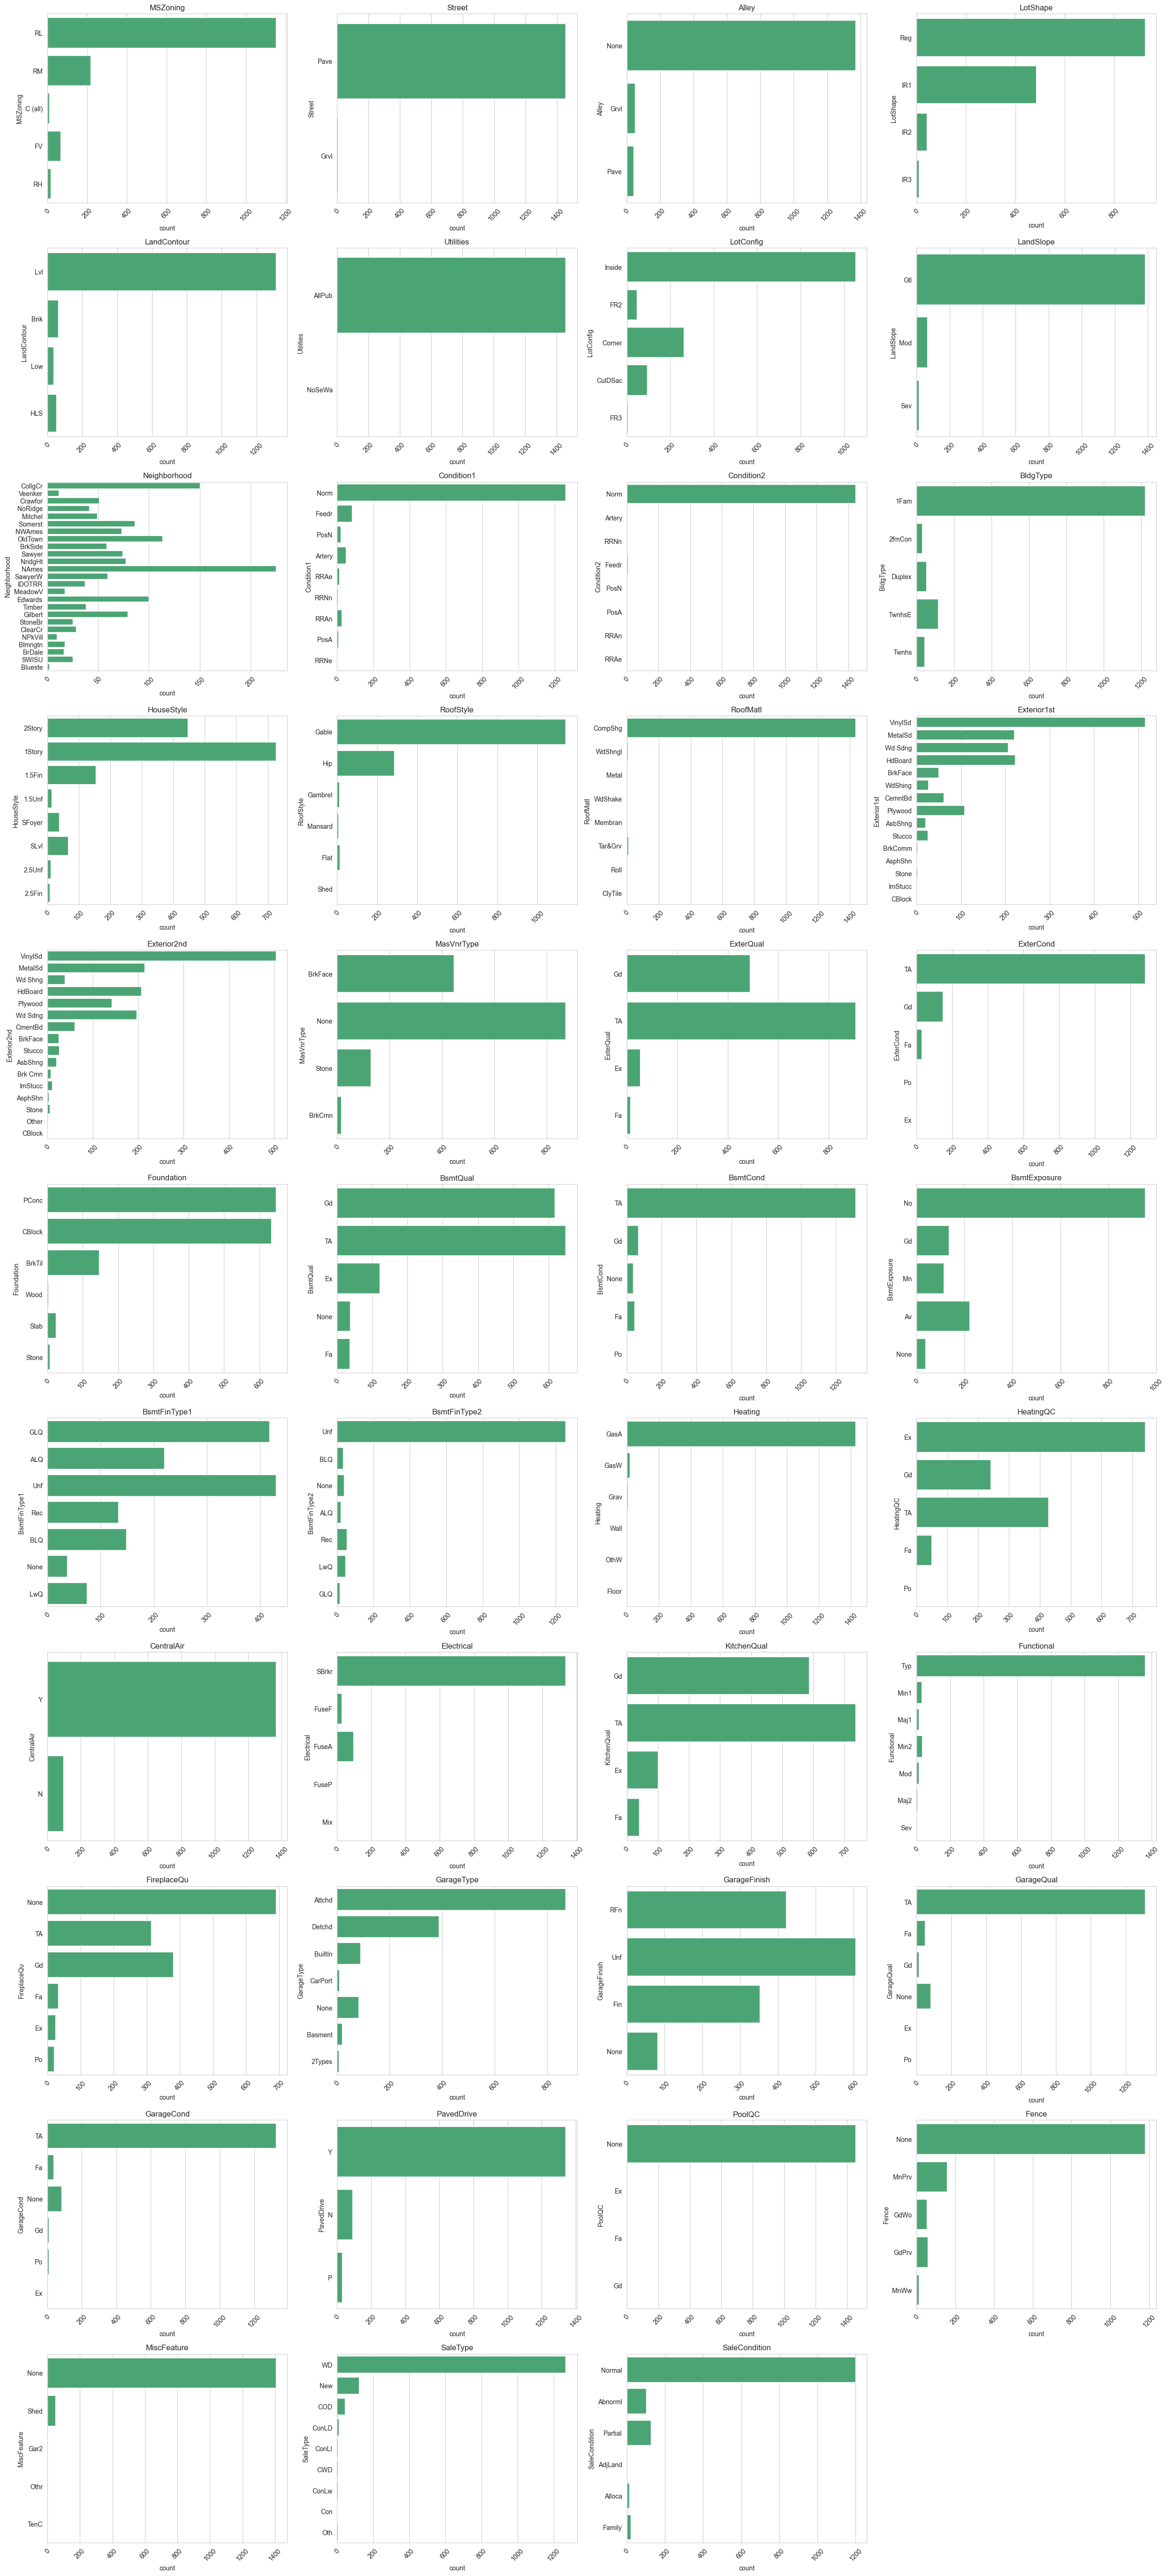

In [352]:
import math

cat_features = df_clean.select_dtypes(include='object').columns.tolist()
n_cols = 4
n_rows = math.ceil(len(cat_features) / n_cols)

plt.figure(figsize=(25, 5 * n_rows))

for i, col in enumerate(cat_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(data=df, y=col, color='mediumseagreen')
    plt.title(col)
    plt.xticks(rotation=45)

plt.savefig("../images/eda_plots/categorical_feature.png")
plt.tight_layout()
plt.show()

In [353]:
#imblanced data
for col in ['Neighborhood', 'Utilities', 'Street', 'SaleCondition', 'SaleType']:
    print(f"--- {col} ---")
    print(df_clean[col].value_counts(normalize=True).round(3) * 100)
    print()

--- Neighborhood ---
Neighborhood
NAmes      15.4
CollgCr    10.3
OldTown     7.7
Edwards     6.8
Somerst     5.9
Gilbert     5.4
NridgHt     5.3
Sawyer      5.1
NWAmes      5.0
SawyerW     4.0
BrkSide     4.0
Crawfor     3.5
Mitchel     3.4
NoRidge     2.8
Timber      2.6
IDOTRR      2.5
ClearCr     1.9
StoneBr     1.7
SWISU       1.7
MeadowV     1.2
Blmngtn     1.2
BrDale      1.1
Veenker     0.8
NPkVill     0.6
Blueste     0.1
Name: proportion, dtype: float64

--- Utilities ---
Utilities
AllPub    99.9
NoSeWa     0.1
Name: proportion, dtype: float64

--- Street ---
Street
Pave    99.6
Grvl     0.4
Name: proportion, dtype: float64

--- SaleCondition ---
SaleCondition
Normal     82.1
Partial     8.6
Abnorml     6.9
Family      1.4
Alloca      0.8
AdjLand     0.3
Name: proportion, dtype: float64

--- SaleType ---
SaleType
WD       86.8
New       8.4
COD       2.9
ConLD     0.6
ConLI     0.3
ConLw     0.3
CWD       0.3
Oth       0.2
Con       0.1
Name: proportion, dtype: float64



### 5.3 Correlation of numerical feature with Saleprice

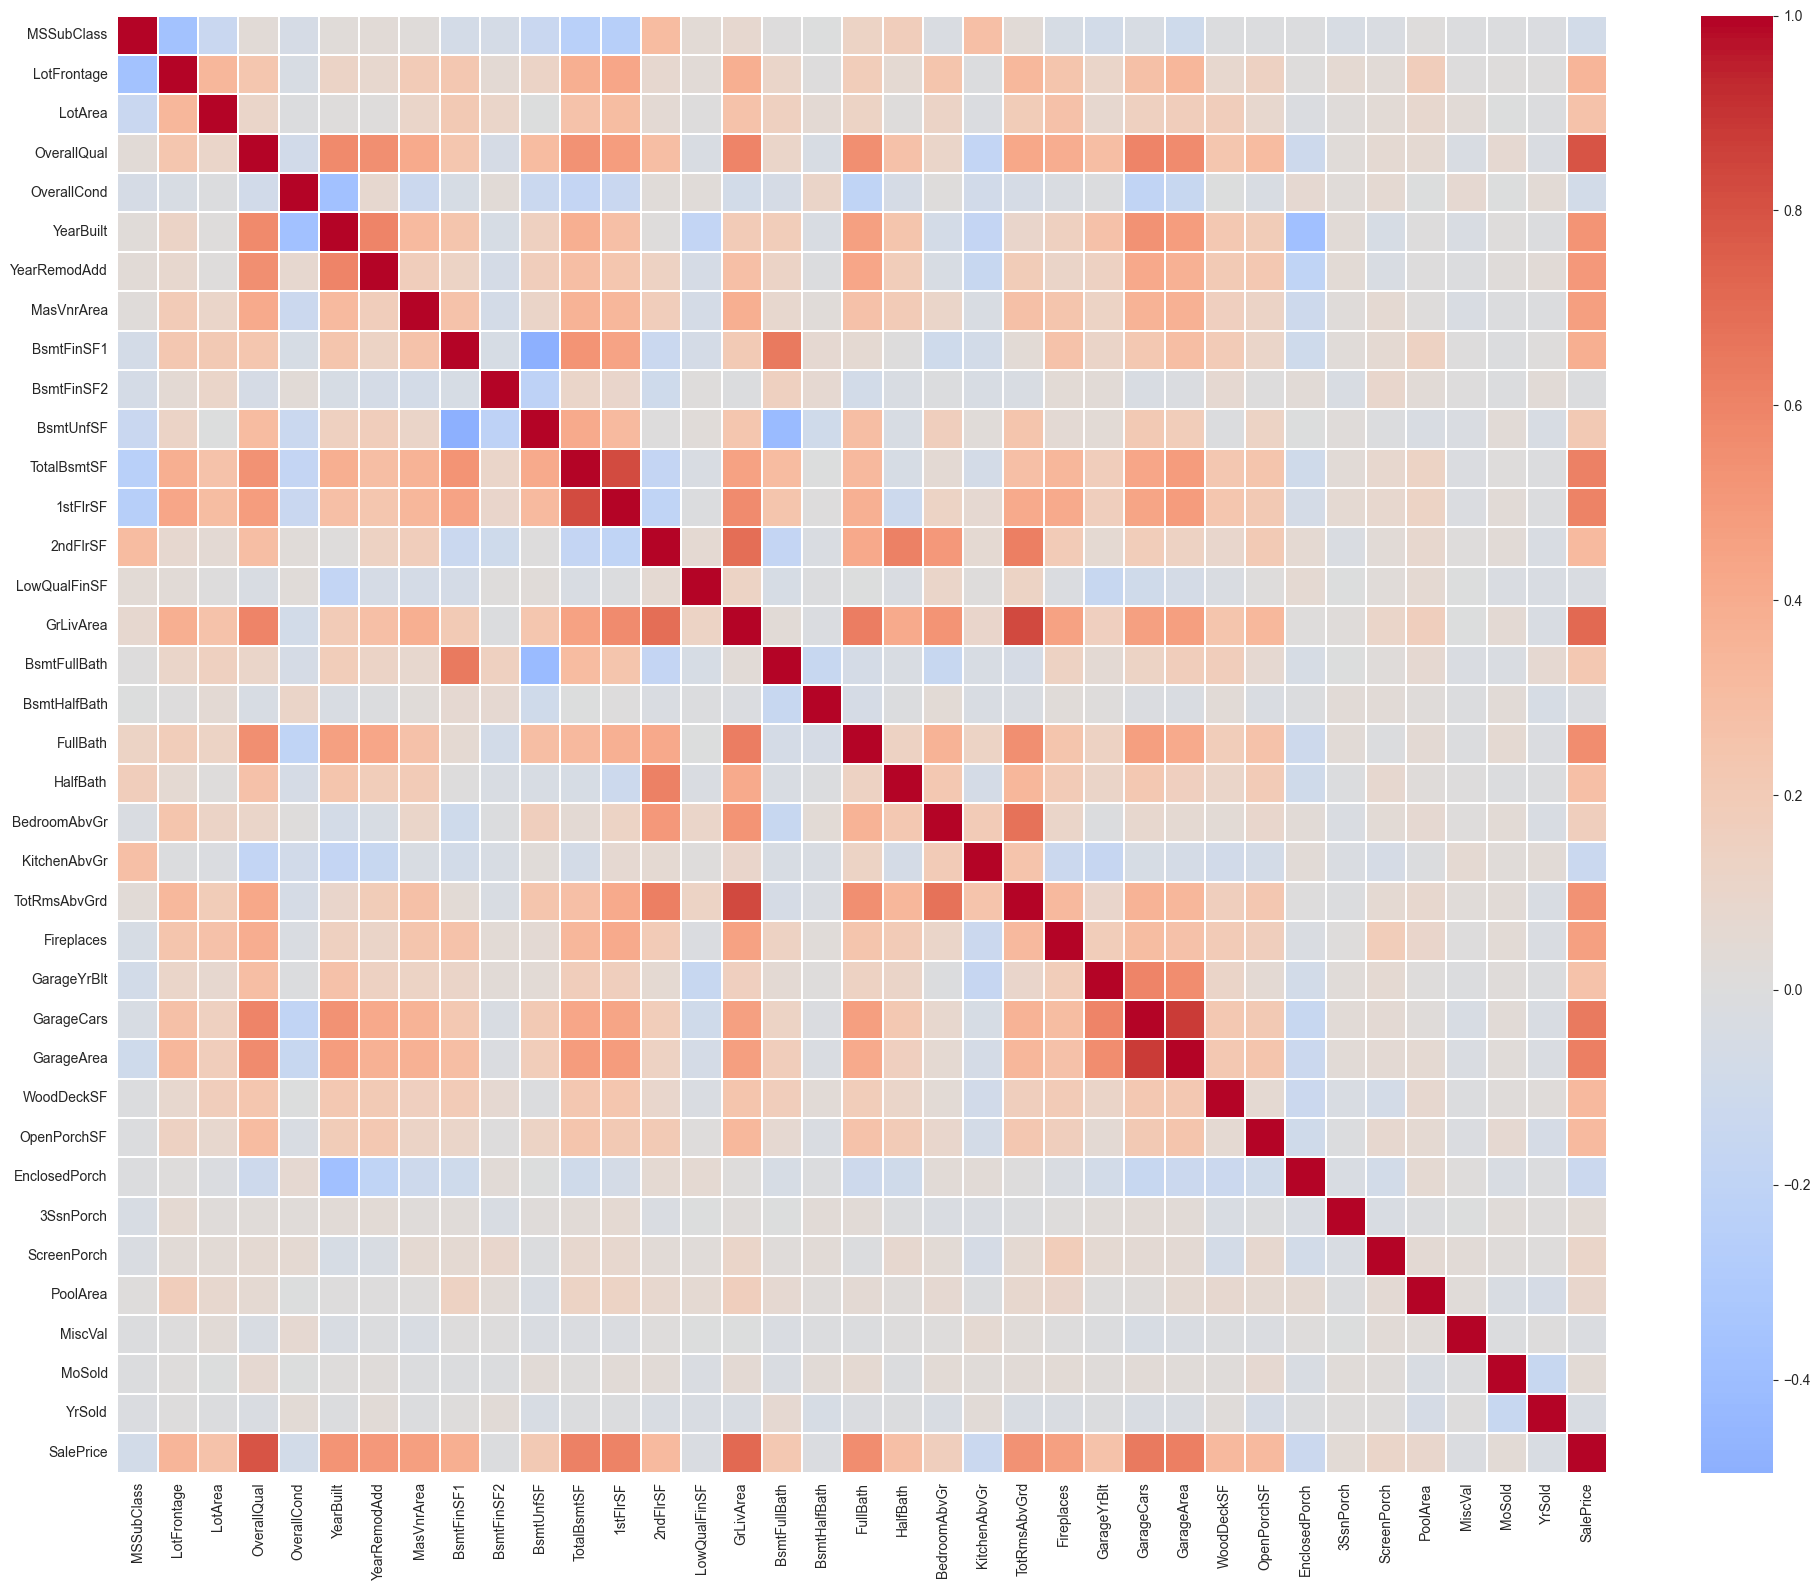

In [354]:
corr = df_clean[num_features + ["SalePrice"]].corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr,center=0, cmap='coolwarm', linewidths=0.2)
plt.tight_layout()
plt.savefig("../images/eda_plots/Correlation_of_numericalFeature_with_SalePrice.png")
plt.show()

In [355]:
postive_feature = corr["SalePrice"].drop("SalePrice").sort_values(ascending=False)
print('Top 10 positively correlated features with SalePrice:')
print(postive_feature.head(10))

print('Top 10 negatively correlated features with SalePrice:')
print(postive_feature.tail(10))

Top 10 positively correlated features with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64
Top 10 negatively correlated features with SalePrice:
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


### 5.4 Corelation of top feature with SalePrice

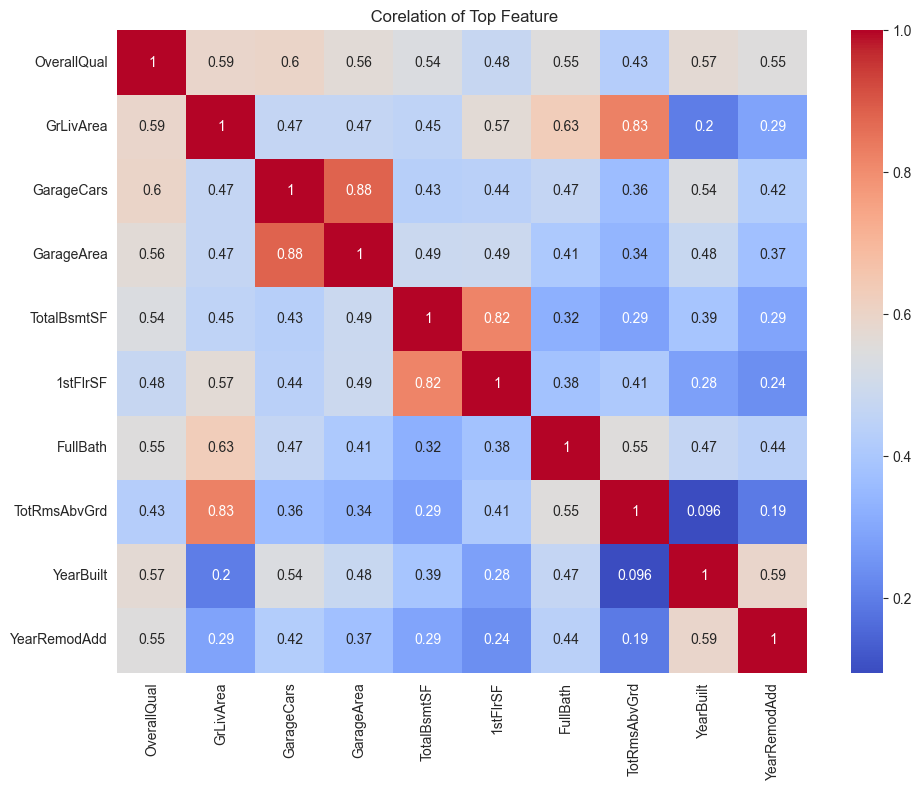

In [356]:
top_corr = postive_feature.head(10).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[top_corr].corr(), cmap="coolwarm", annot=True, )
plt.title(" Corelation of Top Feature")
plt.tight_layout()
plt.savefig("../images/eda_plots/Corelation_top_feature.png")
plt.show()

### 5.4 Bivariant Analysis - Numerical v/s Numerical

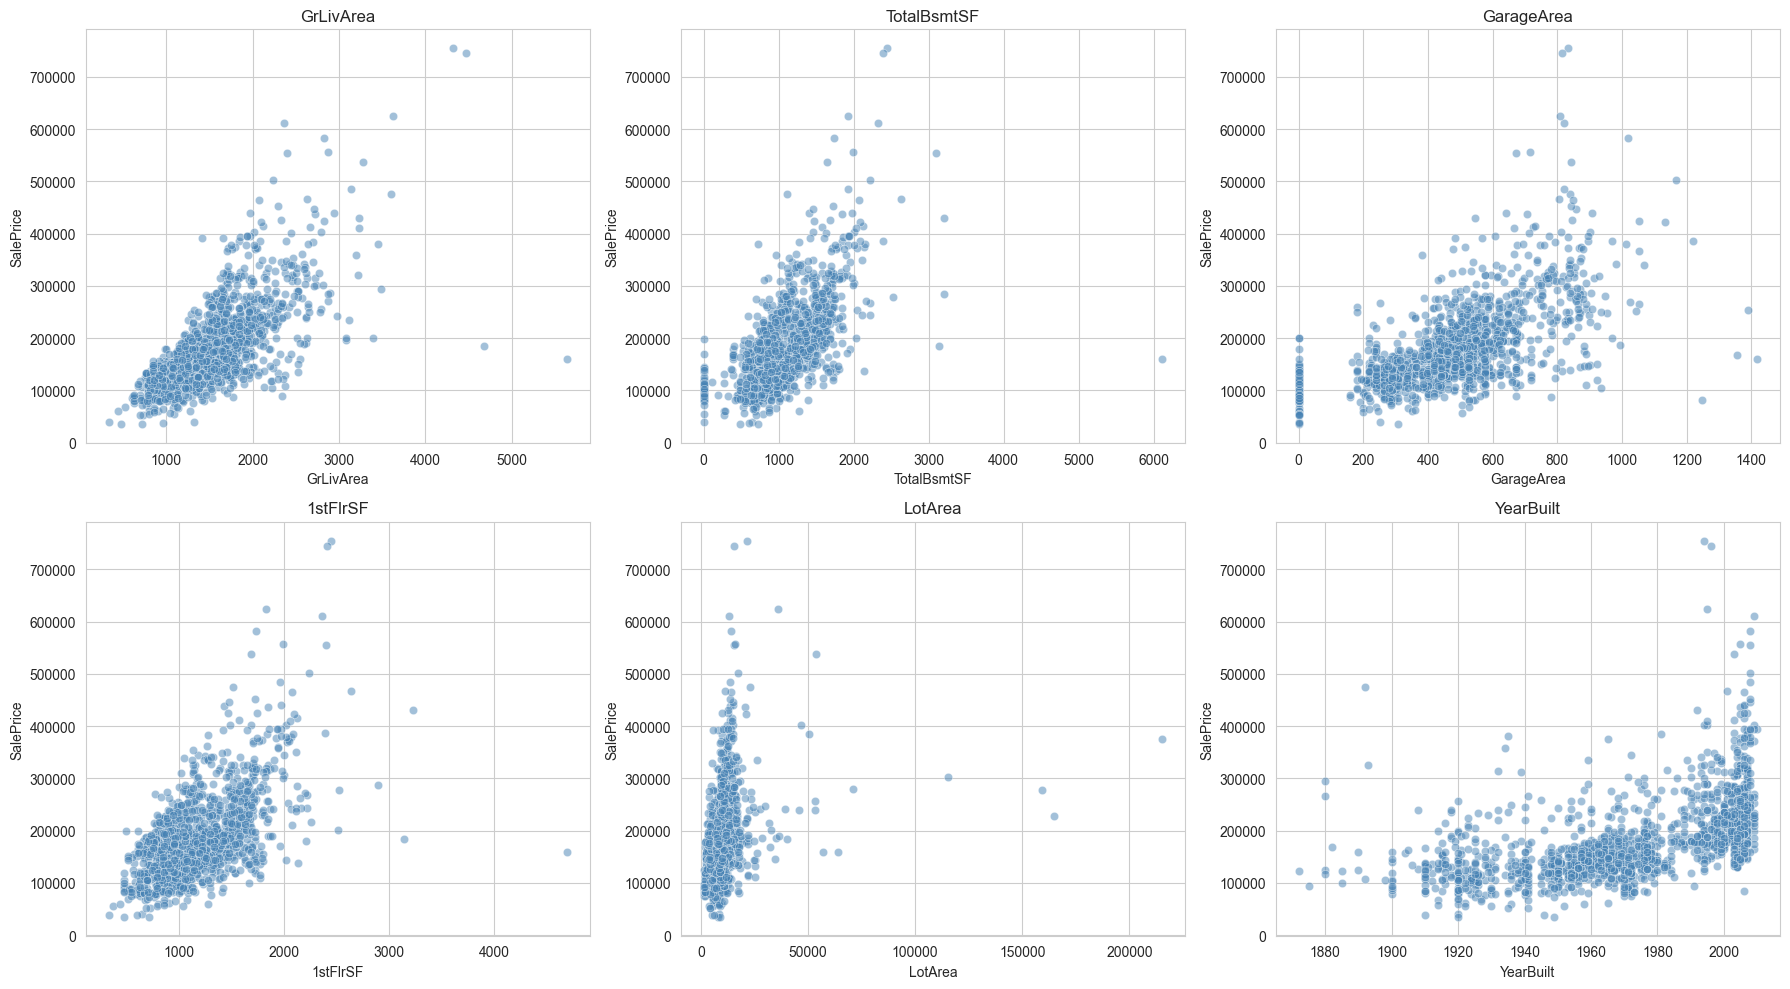

In [357]:
import math
pairs = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', '1stFlrSF', 'LotArea', 'YearBuilt']
n_cols = 3
n_rows = math.ceil(len(pairs) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(pairs, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.scatterplot(data=df_clean, x=col, y='SalePrice', alpha=0.5, color='steelblue')
    plt.title(col)

plt.savefig("../images/eda_plots/Numerical_vs_numerical.png")
plt.tight_layout()
plt.show()

### 5.5 Bivariant Analysis - Numerical v/s Categorical

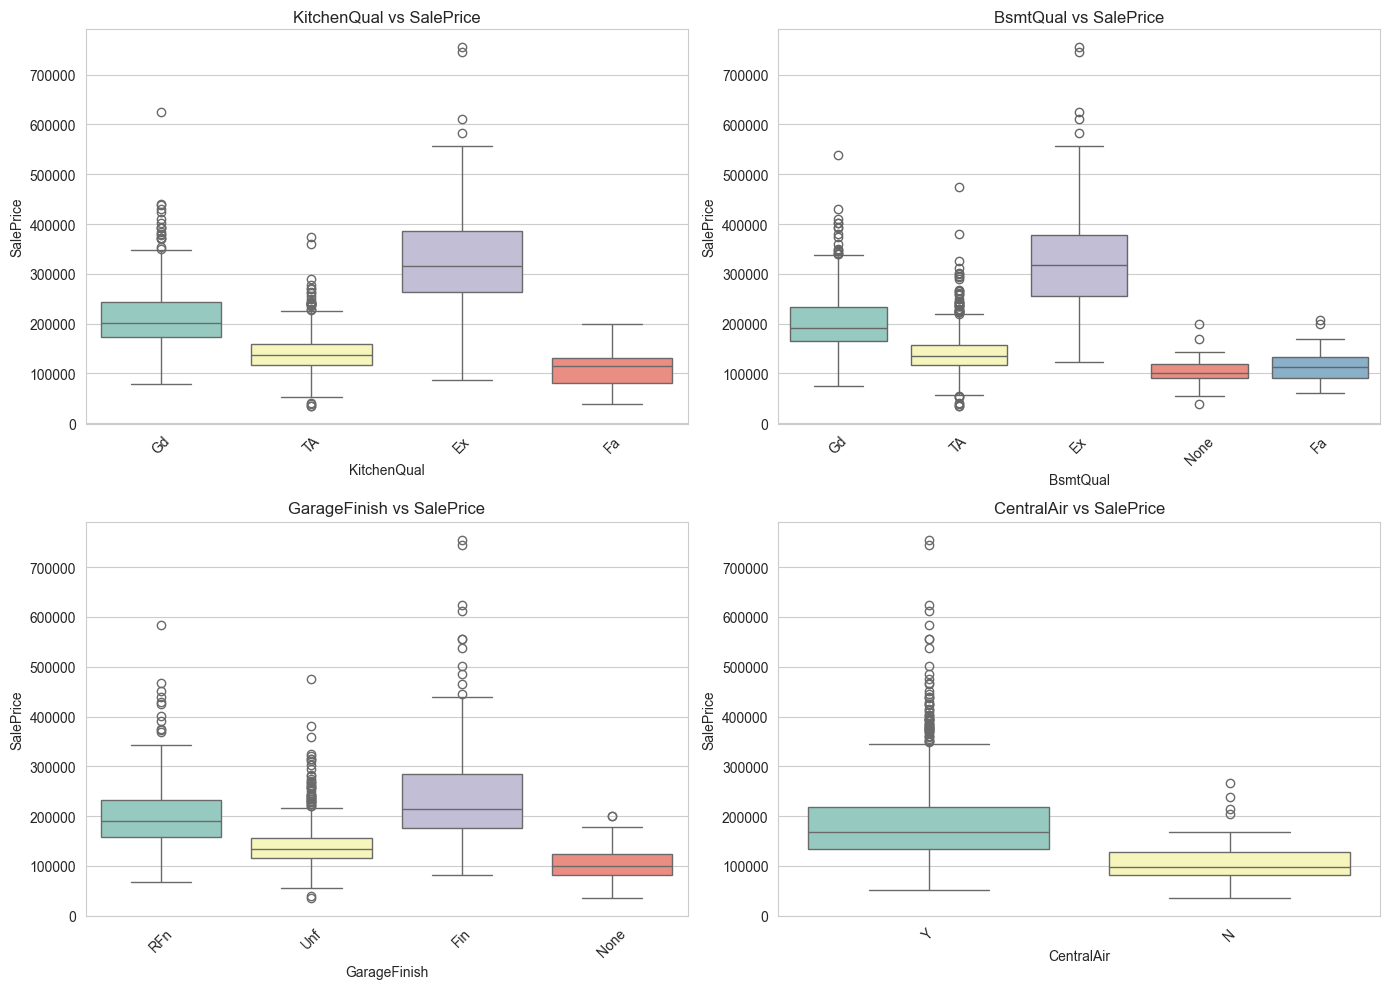

In [358]:
plt.figure(figsize=(14, 10))

for i, col in enumerate(['KitchenQual', 'BsmtQual', 'GarageFinish', 'CentralAir'], 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=col, y='SalePrice', palette="Set3")
    plt.title(f'{col} vs SalePrice')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/eda_plots/categorical_vs_price_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

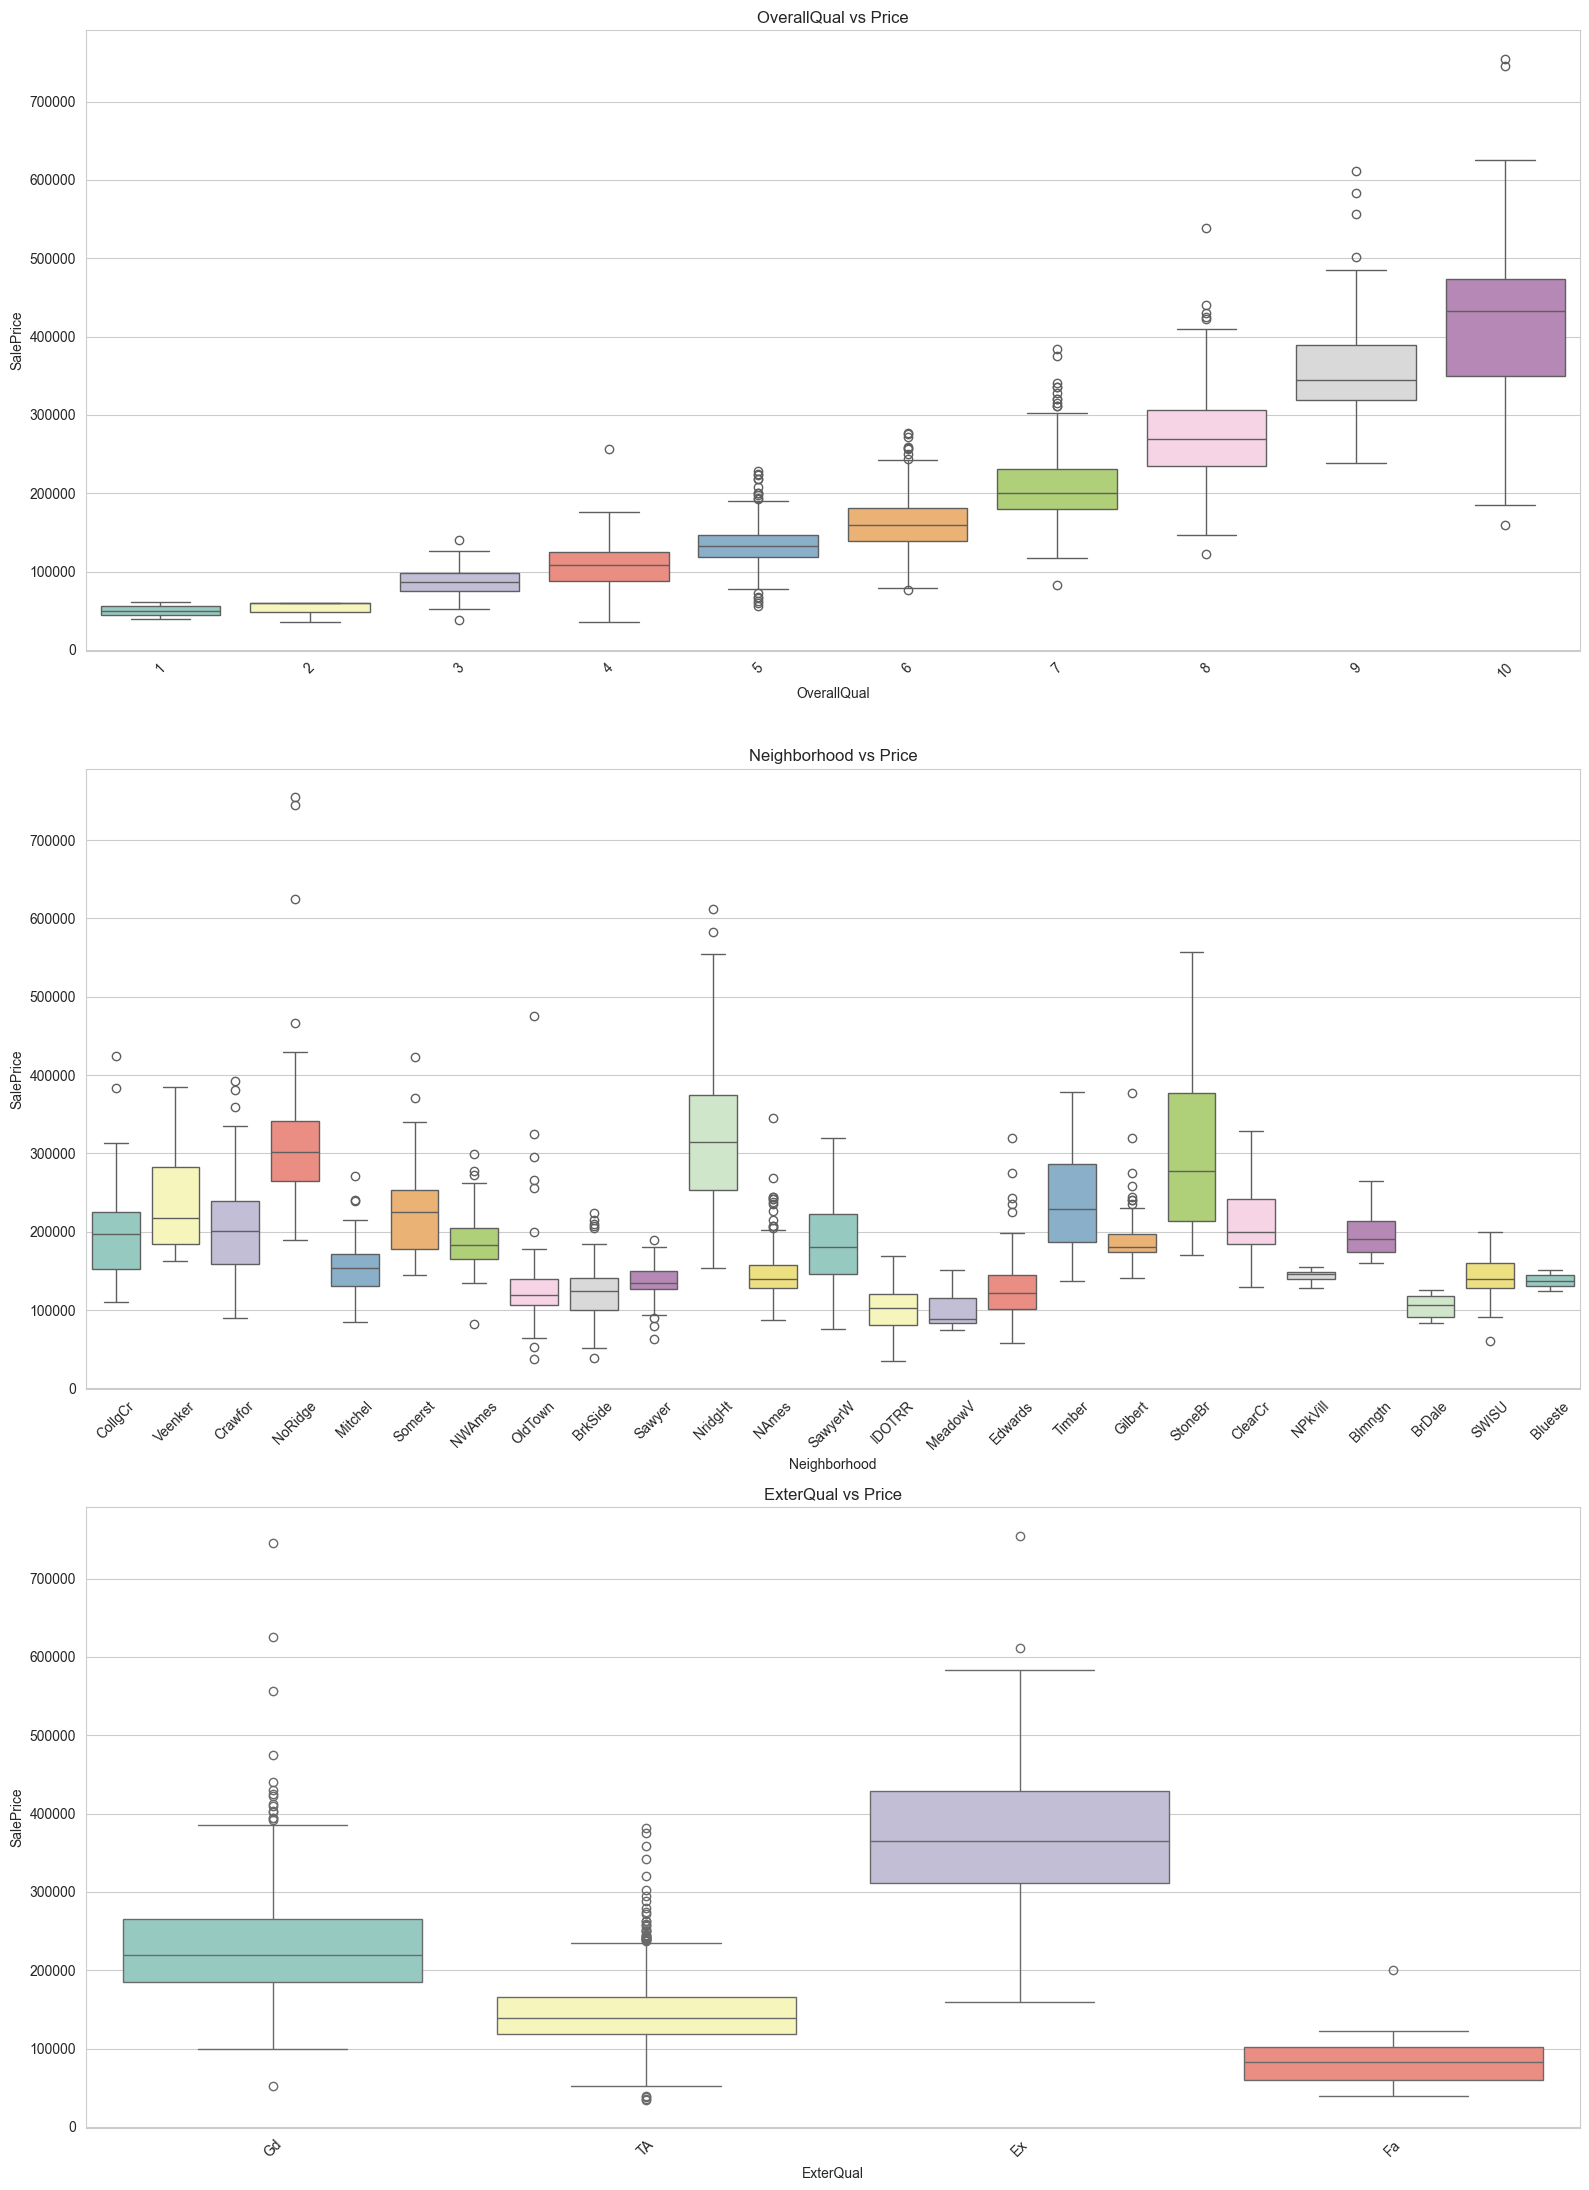

In [359]:
plt.figure(figsize=(16, 22))

for i, col in enumerate(['OverallQual', 'Neighborhood', 'ExterQual'], 1):
    plt.subplot(3, 1, i)
    sns.boxplot(data=df, x=col, y='SalePrice', palette="Set3")
    plt.title(f'{col} vs Price')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/eda_plots/categorical_vs_SalePrice_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [360]:
outliers = df_clean[(df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000)]
df_clean = df_clean.drop(outliers.index)

### 5.5 Multivariant Analysis

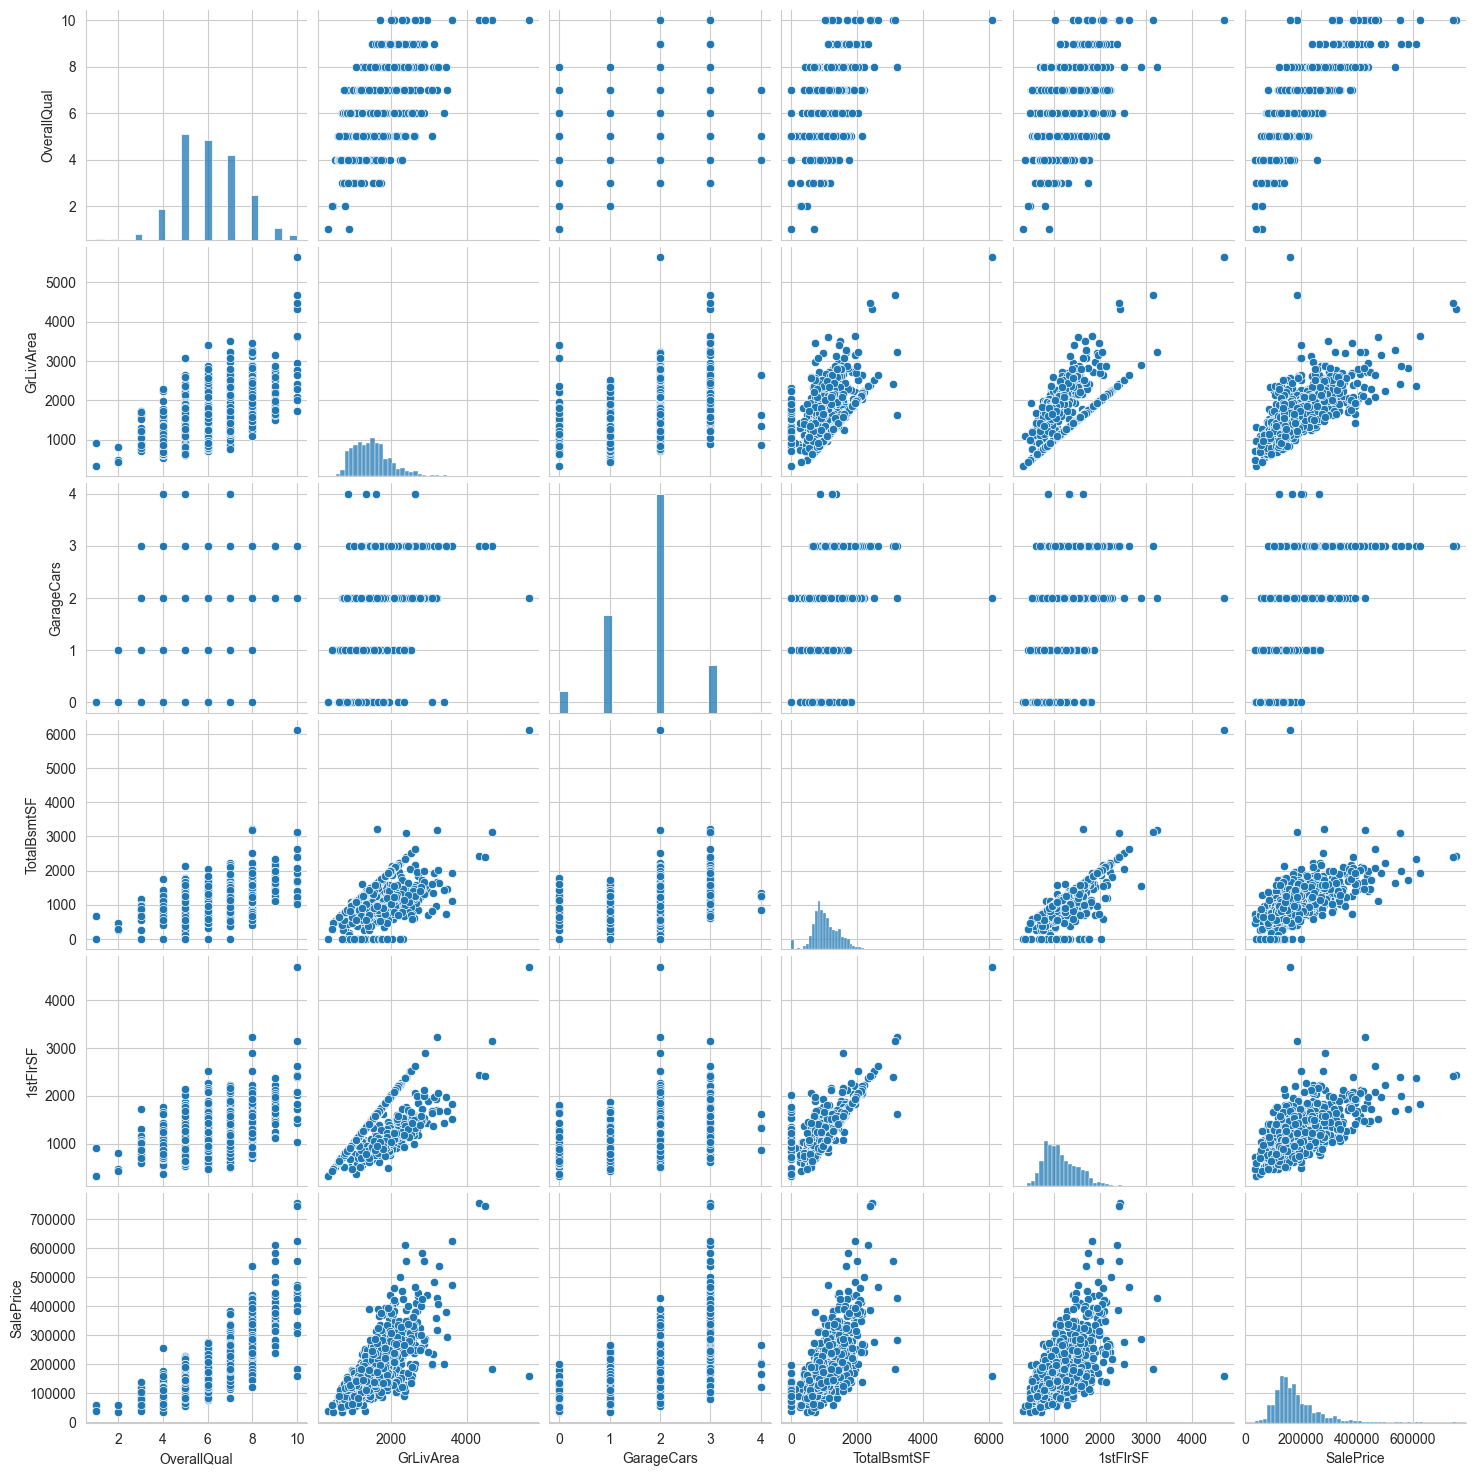

In [361]:
pairplot_features = ['OverallQual','GrLivArea', 'GarageCars','TotalBsmtSF','1stFlrSF','SalePrice'
]
sns.pairplot(df[pairplot_features])
# plt.title("Pairwise Relationships Among Top Predictors")
plt.savefig("../images/eda_plots/Pairplot.png")
plt.show()

## 6. Feature Engineering

In [362]:
df_fe = df_clean.copy()

# Engineered features
df_fe['HouseAge'] = df_fe['YrSold'] - df_fe['YearBuilt']
df_fe['RemodAge'] = df_fe['YrSold'] - df_fe['YearRemodAdd']
df_fe['TotalSF'] = df_fe['TotalBsmtSF'] + df_fe['1stFlrSF'] + df_fe['2ndFlrSF']
df_fe['TotalBath'] = (df_fe['FullBath'] + 0.5 * df_fe['HalfBath'] +
                       df_fe['BsmtFullBath'] + 0.5 * df_fe['BsmtHalfBath'])
df_fe['TotalPorchSF'] = (df_fe['OpenPorchSF'] + df_fe['EnclosedPorch'] +
                          df_fe['3SsnPorch'] + df_fe['ScreenPorch'])
df_fe['HasPool'] = (df_fe['PoolArea'] > 0).astype(int)
df_fe['HasGarage'] = (df_fe['GarageArea'] > 0).astype(int)
df_fe['HasFireplace'] = (df_fe['Fireplaces'] > 0).astype(int)
df_fe['HasRemodeled'] = (df_fe['YearBuilt'] != df_fe['YearRemodAdd']).astype(int)

# Drop near-constant / low-signal columns identified during EDA
drop_low_signal = ['Utilities', 'Street', 'PoolQC', 'MiscFeature', 'PoolArea',
                    'YrSold', 'YearBuilt', 'YearRemodAdd']
df_fe = df_fe.drop(columns=[c for c in drop_low_signal if c in df_fe.columns])

print('Shape after feature engineering:', df_fe.shape)
df_fe.head()

Shape after feature engineering: (1458, 82)


,MSSubClass,MSZoning,LotFrontage,LotArea,Alley,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,Fence,MiscVal,MoSold,SaleType,SaleCondition,SalePrice,SalePrice_log,HouseAge,RemodAge,TotalSF,TotalBath,TotalPorchSF,HasPool,HasGarage,HasFireplace,HasRemodeled
0,60,RL,65.0,8450,None,Reg,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,None,0,2,WD,Normal,208500,12.247699,5,5,2566,3.5,61,0,1,0,0
1,20,RL,80.0,9600,None,Reg,Lvl,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,None,0,5,WD,Normal,181500,12.109016,31,31,2524,2.5,0,0,1,1,0
2,60,RL,68.0,11250,None,IR1,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,None,0,9,WD,Normal,223500,12.317171,7,6,2706,3.5,42,0,1,1,1
3,70,RL,60.0,9550,None,IR1,Lvl,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,None,0,2,WD,Abnorml,140000,11.849405,91,36,2473,2.0,307,0,1,1,1
4,60,RL,84.0,14260,None,IR1,Lvl,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,None,0,12,WD,Normal,250000,12.429220,8,8,3343,3.5,84,0,1,1,0


In [363]:
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']
for c in ordinal_cols:
    df_fe[c] = df_fe[c].map(qual_map).fillna(0).astype(int)

In [364]:
X = df_fe.drop(columns=["SalePrice", "SalePrice_log"])
y = df_fe["SalePrice_log"]   # model on the log-transformed target

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

In [365]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


## 7. Train Test Split

In [366]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (1166, 80) Test: (292, 80)


## 8. Model Selection

In [367]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=10, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=10000),
    'DecisionTree': DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    'KNN': KNeighborsRegressor(n_neighbors=8),
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=300, random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'SVR': SVR(kernel='rbf', C=10, epsilon=0.01),
    'XGBoost': xgb.XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4,
                                 random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    neg_mse_scores = cross_val_score(pipe, X_train, y_train, cv=kf,
                                      scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse_scores = -neg_mse_scores
    r2_scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
    cv_results.append({
        'Model': name,
        'CV_RMSE_mean': rmse_scores.mean(),
        'CV_RMSE_std': rmse_scores.std(),
        'CV_R2_mean': r2_scores.mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values('CV_RMSE_mean')
cv_results_df

,Model,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean
3,ElasticNet,0.112390,0.009766,0.918687
1,Ridge,0.113325,0.010515,0.917231
2,Lasso,0.114026,0.009188,0.916251
7,GradientBoosting,0.119871,0.012087,0.907837
10,XGBoost,0.120095,0.012255,0.907592
0,LinearRegression,0.123628,0.014106,0.900372
6,RandomForest,0.135138,0.012847,0.883077
9,SVR,0.147335,0.011370,0.858886
8,AdaBoost,0.163884,0.010305,0.827670
5,KNN,0.165030,0.014378,0.825080


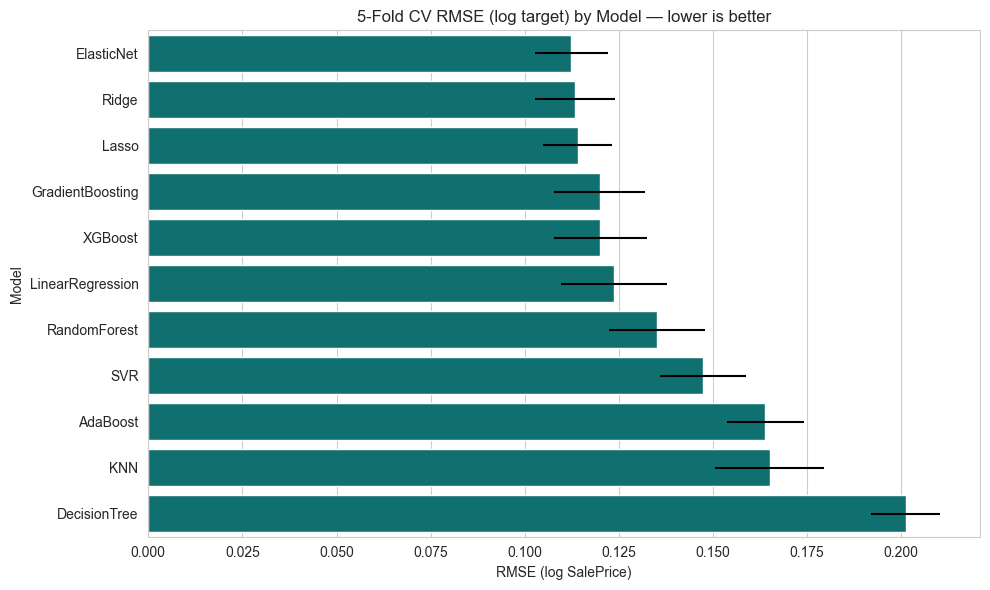

In [369]:
plt.figure(figsize=(10, 6))
order = cv_results_df.sort_values('CV_RMSE_mean')['Model']
sns.barplot(data=cv_results_df, x='CV_RMSE_mean', y='Model', order=order, color='teal',
            xerr=cv_results_df.set_index('Model').loc[order, 'CV_RMSE_std'])
plt.title('5-Fold CV RMSE (log target) by Model — lower is better')
plt.xlabel('RMSE (log SalePrice)')
plt.tight_layout()
plt.savefig("../images/model_performance_plots/model.png")
plt.show()

In [370]:
def evaluate_on_test(name, model, X_train, y_train, X_test, y_test):
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)

    rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))
    r2_log = r2_score(y_test, pred_log)

    # back-transform to dollars for interpretability
    pred_dollars = np.expm1(pred_log)
    true_dollars = np.expm1(y_test)
    rmse_dollars = np.sqrt(mean_squared_error(true_dollars, pred_dollars))
    mae_dollars = mean_absolute_error(true_dollars, pred_dollars)

    return {
        'Model': name, 'Test_RMSE_log': rmse_log, 'Test_R2_log': r2_log,
        'Test_RMSE_dollars': rmse_dollars, 'Test_MAE_dollars': mae_dollars
    }, pipe

top_models = cv_results_df.sort_values('CV_RMSE_mean').head(6)['Model'].tolist()
print('Evaluating top models on the test set:', top_models)

test_results = []
fitted_pipes = {}
for name in top_models:
    res, pipe = evaluate_on_test(name, models[name], X_train, y_train, X_test, y_test)
    test_results.append(res)
    fitted_pipes[name] = pipe

test_results_df = pd.DataFrame(test_results).sort_values('Test_RMSE_log')
test_results_df

Evaluating top models on the test set: ['ElasticNet', 'Ridge', 'Lasso', 'GradientBoosting', 'XGBoost', 'LinearRegression']


,Model,Test_RMSE_log,Test_R2_log,Test_RMSE_dollars,Test_MAE_dollars
0,ElasticNet,0.117408,0.918229,19745.031492,14290.814599
2,Lasso,0.118118,0.917238,19389.506662,14096.879318
3,GradientBoosting,0.119904,0.914715,19462.277708,13988.050575
4,XGBoost,0.121381,0.912602,19524.761849,14214.446624
1,Ridge,0.121492,0.912442,20363.594771,14648.972368
5,LinearRegression,0.131701,0.897108,22378.152740,15751.814501


Best model on held-out test set: ElasticNet


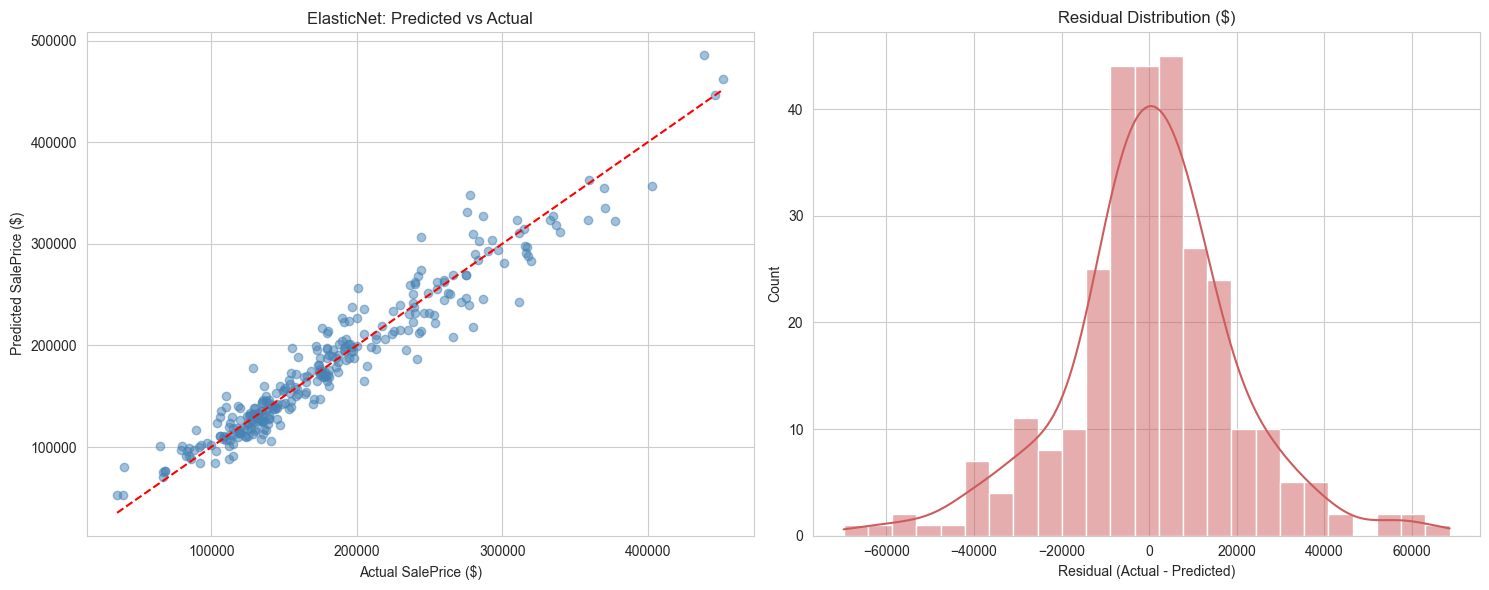

In [371]:
best_model_name = test_results_df.iloc[0]['Model']
best_pipe = fitted_pipes[best_model_name]
print(f'Best model on held-out test set: {best_model_name}')

pred_log = best_pipe.predict(X_test)
pred_dollars = np.expm1(pred_log)
true_dollars = np.expm1(y_test)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(true_dollars, pred_dollars, alpha=0.5, color='steelblue')
axes[0].plot([true_dollars.min(), true_dollars.max()], [true_dollars.min(), true_dollars.max()], 'r--')
axes[0].set_xlabel('Actual SalePrice ($)')
axes[0].set_ylabel('Predicted SalePrice ($)')
axes[0].set_title(f'{best_model_name}: Predicted vs Actual')

residuals = true_dollars - pred_dollars
sns.histplot(residuals, kde=True, ax=axes[1], color='indianred')
axes[1].set_title('Residual Distribution ($)')
axes[1].set_xlabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.savefig("../images/model_performance_plots/best_model.png")
plt.show()

## 7. Hyperprameter Tunning

In [372]:
param_distributions = {
    'XGBoost': {
        'model__n_estimators': [300, 500, 800, 1000],
        'model__max_depth': [3, 4, 5, 6],
        'model__learning_rate': [0.01, 0.02, 0.05, 0.1],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0],
        'model__min_child_weight': [1, 3, 5]
    },
    'GradientBoosting': {
        'model__n_estimators': [200, 300, 500],
        'model__max_depth': [2, 3, 4],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.6, 0.8, 1.0]
    },
    'RandomForest': {
        'model__n_estimators': [200, 400, 600],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    },
    'Ridge': {'model__alpha': [0.1, 1, 5, 10, 20, 50]},
    'Lasso': {'model__alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01]}
}

# Tune whichever model performed best on the test set (falls back to a sensible default)
tune_target = best_model_name if best_model_name in param_distributions else 'XGBoost'
print(f'Tuning: {tune_target}')

base_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', models[tune_target])])

search = RandomizedSearchCV(
    base_pipe,
    param_distributions=param_distributions[tune_target],
    n_iter=25,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)
search.fit(X_train, y_train)

print('Best CV RMSE (log):', -search.best_score_)
print('Best params:', search.best_params_)

Tuning: XGBoost
Best CV RMSE (log): 0.11751861286535399
Best params: {'model__subsample': 0.8, 'model__n_estimators': 1000, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.6}


In [373]:
tuned_pipe = search.best_estimator_
pred_log_tuned = tuned_pipe.predict(X_test)
rmse_log_tuned = np.sqrt(mean_squared_error(y_test, pred_log_tuned))
r2_log_tuned = r2_score(y_test, pred_log_tuned)

pred_dollars_tuned = np.expm1(pred_log_tuned)
rmse_dollars_tuned = np.sqrt(mean_squared_error(np.expm1(y_test), pred_dollars_tuned))

print(f'Tuned {tune_target} — Test RMSE (log): {rmse_log_tuned:.4f}, R2: {r2_log_tuned:.4f}, '
      f'RMSE ($): {rmse_dollars_tuned:,.0f}')

before_row = test_results_df[test_results_df['Model'] == tune_target]
print('\nBefore tuning:')
print(before_row[['Model', 'Test_RMSE_log', 'Test_R2_log', 'Test_RMSE_dollars']])
print(f'\nAfter tuning:  RMSE(log)={rmse_log_tuned:.4f}  R2={r2_log_tuned:.4f}  RMSE($)={rmse_dollars_tuned:,.0f}')

Tuned XGBoost — Test RMSE (log): 0.1148, R2: 0.9219, RMSE ($): 18,334

Before tuning:
     Model  Test_RMSE_log  Test_R2_log  Test_RMSE_dollars
4  XGBoost       0.121381     0.912602       19524.761849

After tuning:  RMSE(log)=0.1148  R2=0.9219  RMSE($)=18,334


In [ ]:
final_summary = test_results_df.copy()
final_summary = final_summary.append(
    {'Model': f'{tune_target} (tuned)', 'Test_RMSE_log': rmse_log_tuned,
     'Test_R2_log': r2_log_tuned, 'Test_RMSE_dollars': rmse_dollars_tuned,
     'Test_MAE_dollars': mean_absolute_error(np.expm1(y_test), pred_dollars_tuned)},
    ignore_index=True
) if hasattr(test_results_df, 'append') else pd.concat([
    test_results_df,
    pd.DataFrame([{'Model': f'{tune_target} (tuned)', 'Test_RMSE_log': rmse_log_tuned,
                    'Test_R2_log': r2_log_tuned, 'Test_RMSE_dollars': rmse_dollars_tuned,
                    'Test_MAE_dollars': mean_absolute_error(np.expm1(y_test), pred_dollars_tuned)}])
], ignore_index=True)

final_summary = final_summary.sort_values('Test_RMSE_log').reset_index(drop=True)
final_summary


,Model,Test_RMSE_log,Test_R2_log,Test_RMSE_dollars,Test_MAE_dollars
0,XGBoost (tuned),0.114758,0.921879,18334.083158,13508.157066
1,ElasticNet,0.117408,0.918229,19745.031492,14290.814599
2,Lasso,0.118118,0.917238,19389.506662,14096.879318
3,GradientBoosting,0.119904,0.914715,19462.277708,13988.050575
4,XGBoost,0.121381,0.912602,19524.761849,14214.446624
5,Ridge,0.121492,0.912442,20363.594771,14648.972368
6,LinearRegression,0.131701,0.897108,22378.152740,15751.814501


## Model Saving

In [375]:
import pickle

with open("../models/best_model.pkl", "wb") as f:
    pickle.dump(best_pipe, f)